## Composite ranking baseline

Builds the ranked baseline used by the evaluation notebooks: per-source z-score and percentile ranks across DepMap, HPA, GEO and proteomics, fused into a composite score for one target gene.

Reads: the harmonised expression, proteomics and cell line tables. Writes: `processed/ENSG00000146648_composite_baseline.parquet` (EGFR) and `processed/ENSG00000141736_composite_baseline.parquet` (ERBB2).

In [1]:
import pandas as pd

hpa = pd.read_csv("../../data/AZ_harmonized_data/fact_expression_hpa.csv")  
print(hpa.shape)
print(hpa.columns.tolist())
hpa.head()

(24315372, 10)
['ACH_ID', 'CVCL_ID', 'ensembl_id', 'hugo_symbol', 'source', 'tpm', 'pTPM', 'nTPM', 'log2_tpm_plus1', 'is_expressed']


,ACH_ID,CVCL_ID,ensembl_id,hugo_symbol,source,tpm,pTPM,nTPM,log2_tpm_plus1,is_expressed
0,ACH-001001,CVCL_2270,ENSG00000000003,TSPAN6,hpa,22.0,27.6,25.9,4.523562,True
1,ACH-000956,CVCL_1045,ENSG00000000003,TSPAN6,hpa,2.8,3.6,2.7,1.925999,True
2,ACH-000948,CVCL_1046,ENSG00000000003,TSPAN6,hpa,6.2,7.5,7.5,2.847997,True
3,ACH-000011,CVCL_7935,ENSG00000000003,TSPAN6,hpa,14.2,18.7,25.4,3.925999,True
4,ACH-000026,CVCL_7937,ENSG00000000003,TSPAN6,hpa,13.0,17.1,18.5,3.807355,True


In [2]:
print(hpa["source"].unique())

['hpa']


In [3]:
geo = pd.read_csv("../../data/AZ_harmonized_data/geo.csv")  
print(geo.shape)
print(geo.columns.tolist())
geo.head()

C:\Users\HP\AppData\Local\Temp\ipykernel_42344\1781234455.py:1: DtypeWarning: Columns (0,1) have mixed types. Specify dtype option on import or set low_memory=False.
  geo = pd.read_csv("../../data/AZ_harmonized_data/geo.csv")


(65059038, 8)
['ACH_ID', 'CVCL_ID', 'ensembl_id', 'GSM_ID', 'source', 'tpm', 'log2_tpm_plus1', 'is_expressed']


,ACH_ID,CVCL_ID,ensembl_id,GSM_ID,source,tpm,log2_tpm_plus1,is_expressed
0,ACH-000558,CVCL_0131,ENSG00000000003,GSM101610,geo,33.615700,5.113355,True
1,ACH-000558,CVCL_0131,ENSG00000000005,GSM101610,geo,40.925682,5.389762,True
2,ACH-000558,CVCL_0131,ENSG00000000419,GSM101610,geo,2182.281250,11.092282,True
3,ACH-000558,CVCL_0131,ENSG00000000457,GSM101610,geo,58.934814,5.905322,True
4,ACH-000558,CVCL_0131,ENSG00000000460,GSM101610,geo,136.418900,7.102437,True


In [4]:
# does one cell line have multiple GSM samples?
geo.groupby("ACH_ID")["GSM_ID"].nunique().sort_values(ascending=False).head()

ACH_ID
ACH-002875    108
ACH-001188     67
ACH-000019     49
ACH-000768     41
ACH-000681     31
Name: GSM_ID, dtype: int64

In [5]:
depmap = pd.read_csv("../../data/AZ_harmonized_data/fact_expression_depmap.csv")
print(depmap.shape)
print(depmap.columns.tolist())
depmap.head()

(80039310, 9)
['ACH_ID', 'CVCL_ID', 'ensembl_id', 'hugo_symbol', 'PR_ID', 'source', 'tpm', 'log2_tpm_plus1', 'is_expressed']


,ACH_ID,CVCL_ID,ensembl_id,hugo_symbol,PR_ID,source,tpm,log2_tpm_plus1,is_expressed
0,ACH-001113,CVCL_5480,ENSG00000000005,TNMD,PR-AdBjpG,depmap,0.0,0.000000,False
1,ACH-001289,CVCL_RS25,ENSG00000000005,TNMD,PR-I2AzwG,depmap,0.5,0.584963,False
2,ACH-001339,CVCL_2408,ENSG00000000005,TNMD,PR-5ekAAC,depmap,0.0,0.000000,False
3,ACH-001538,CVCL_M261,ENSG00000000005,TNMD,PR-I21681,depmap,0.0,0.000000,False
4,ACH-000242,CVCL_0036,ENSG00000000005,TNMD,PR-i9DRP1,depmap,0.0,0.000000,False


In [6]:
# does one cell line have multiple PR Ids?
depmap.groupby("ACH_ID")["PR_ID"].nunique().sort_values(ascending=False).head()

ACH_ID
ACH-000029    2
ACH-000556    2
ACH-000328    2
ACH-000700    2
ACH-000517    2
Name: PR_ID, dtype: int64

In [7]:
# check the PR split 
print(depmap.groupby("ACH_ID")["PR_ID"].nunique().value_counts())

PR_ID
1    1463
2      16
Name: count, dtype: int64


In [8]:
print("depmap:", depmap.shape)
print("hpa:", hpa.shape)
print("geo:", geo.shape)

depmap: (80039310, 9)
hpa: (24315372, 10)
geo: (65059038, 8)


In [9]:
import numpy as np

for name, df, raw_col in [("depmap", depmap, "tpm"),
                          ("hpa",    hpa,    "tpm"),
                          ("geo",    geo,    "tpm")]:
    s = df.head(200000)
    diff = (np.log2(s[raw_col] + 1) - s["log2_tpm_plus1"]).abs().max()
    print(f"{name:7s} max diff = {diff}")

depmap  max diff = 8.881784197001252e-16
hpa     max diff = 1.7763568394002505e-15
geo     max diff = 1.7763568394002505e-15


In [10]:
# Load harmonized proteomics data instead of the raw file
fact_prot = pd.read_csv("../../data/AZ_harmonized_data/fact_proteomics.csv")

print(fact_prot.shape)
print(fact_prot.columns.tolist())
fact_prot.head(10)

(4709250, 8)
['ACH_ID', 'CVCL_ID', 'ensembl_id', 'uniprot_id', 'hugo_symbol', 'protein_intensity', 'is_detected', 'z_score']


,ACH_ID,CVCL_ID,ensembl_id,uniprot_id,hugo_symbol,protein_intensity,is_detected,z_score
0,ACH-000849,CVCL_0419,ENSG00000163694,A0AV96,RBM47,0.358567,True,0.263468
1,ACH-000441,CVCL_1692,ENSG00000163694,A0AV96,RBM47,-1.112410,True,-0.808447
2,ACH-000248,CVCL_1074,ENSG00000163694,A0AV96,RBM47,0.855575,True,0.625642
3,ACH-000684,CVCL_2983,ENSG00000163694,A0AV96,RBM47,0.061377,True,0.046903
4,ACH-000856,CVCL_1110,ENSG00000163694,A0AV96,RBM47,0.284258,True,0.209318
5,ACH-000348,CVCL_1666,ENSG00000163694,A0AV96,RBM47,-0.485070,True,-0.351298
6,ACH-000062,CVCL_1655,ENSG00000163694,A0AV96,RBM47,0.092390,True,0.069502
7,ACH-000650,CVCL_2075,ENSG00000163694,A0AV96,RBM47,-0.824035,True,-0.598306
8,ACH-000484,CVCL_1790,ENSG00000163694,A0AV96,RBM47,0.926286,True,0.677170
9,ACH-000625,CVCL_0326,ENSG00000163694,A0AV96,RBM47,1.323508,True,0.966630


In [11]:
# load the cell line dictionary
dim = pd.read_csv("../../data/AZ_harmonized_data/dim_cell_lines.csv")
print(dim.columns.tolist())   # check the name column

['ach_id', 'cvcl_id', 'cell_line_name', 'ccle_name', 'primary_disease', 'Subtype', 'lineage', 'lineage_subtype', 'sex', 'age', 'primary_or_metastasis', 'sample_collection_site', 'growth_pattern', 'COSMICID', 'Sanger_Model_ID', 'source', 'metadata_source', 'profile_ids', 'n_profiles', 'has_real_name', 'has_full_metadata']


In [12]:
# rank cell lines for a target gene, pairing each RNA source with proteomics
def rank_cell_lines(ensembl_id, depmap, hpa, geo, fact_prot, dim,
                    penalty=0.75, rna_weight=0.5, value_col="log2_tpm_plus1"):
    """Rank cell lines for one gene across three RNA sources and proteomics.

    Replicates are collapsed to one row per cell line per source, keeping the spread and the replicate count, and each source is percentile-ranked within
    itself so values on different scales never have to be reconciled. Sources are joined with an outer join, so a cell line missing from one source is
    kept rather than dropped and coverage survives as its own signal.
    """
    # collapse replicates to one row per cell line, keeping spread and count
    def aggregate_source(df, name, how="median"):
        sub = df[df["ensembl_id"] == ensembl_id][["ACH_ID", value_col]]
        agg = (sub.groupby("ACH_ID")[value_col]
                  .agg(value=how, spread="std", n_reps="count")   # median resists GEO outlier samples
                  .reset_index())
        agg["spread"] = agg["spread"].fillna(0)                   # single replicate has no spread
        agg["percentile"] = agg["value"].rank(pct=True) * 100     # rank within source only, so scales don't matter
        return agg.rename(columns={
            "value":      f"{name}_value",
            "spread":     f"{name}_spread",
            "n_reps":     f"{name}_n_reps",
            "percentile": f"{name}_percentile",
        })

    # outer join keeps cell lines present in only some sources, preserving the coverage signal
    rna = (aggregate_source(depmap, "depmap")
           .merge(aggregate_source(hpa, "hpa"), on="ACH_ID", how="outer")
           .merge(aggregate_source(geo, "geo"), on="ACH_ID", how="outer"))

    prot = fact_prot[fact_prot["ensembl_id"] == ensembl_id][
        ["ACH_ID", "protein_intensity", "is_detected"]].dropna(subset=["protein_intensity"])
    prot["protein_percentile"] = prot["protein_intensity"].rank(pct=True) * 100

    # left join: most cell lines have no proteomics, and that stays NaN rather than 0
    df = rna.merge(prot, on="ACH_ID", how="left")

    # one confidence per RNA source, each paired against the same protein evidence
    for source in ["depmap", "hpa", "geo"]:
        rna_pct  = df[f"{source}_percentile"]
        prot_pct = df["protein_percentile"]
        has_rna  = rna_pct.notna()
        has_prot = prot_pct.notna()

        strength = np.where(has_prot, rna_weight * rna_pct + (1 - rna_weight) * prot_pct, rna_pct)  # RNA alone if no protein
        gap       = (rna_pct - prot_pct).abs() / 100
        agreement = np.where(has_prot, 1 / (1 + gap), 1.0)                  # nothing to disagree with if protein absent
        coverage  = np.where(has_prot, 1.0, penalty)                        # missing protein reduces, never zeroes

        df[f"{source}_strength"] = pd.Series(strength, index=df.index).where(has_rna)
        df[f"{source}_conf"]     = pd.Series(coverage * agreement, index=df.index).where(has_rna)

    # GEO is the only source with real replication, so it gets a consistency term
    # coefficient of variation is unitless, so comparable across expression levels
    geo_cv = df["geo_spread"] / df["geo_value"].replace(0, np.nan)
    df["geo_conf"] = df["geo_conf"] * (1 / (1 + geo_cv.fillna(0)))

    s_cols = [f"{s}_strength" for s in ["depmap", "hpa", "geo"]]
    c_cols = [f"{s}_conf"     for s in ["depmap", "hpa", "geo"]]

    # mean of the three pairing strengths; already includes protein where available
    df["evidence_score"] = df[s_cols].mean(axis=1)
    df["n_sources"]      = df[s_cols].notna().sum(axis=1)   # coverage across sources
    df["source_std"]     = df[s_cols].std(axis=1).fillna(0) # cross-source disagreement

    # coverage x agreement x mean pairing confidence, each term bounded 0-1
    df["confidence_score"] = ((df["n_sources"] / 3)
                              * (1 / (1 + df["source_std"] / 100))
                              * df[c_cols].mean(axis=1))

    df["weighted_score"] = df["evidence_score"] * df["confidence_score"]

    df = df.merge(dim[["ach_id", "cell_line_name", "primary_disease", "lineage"]],
                  left_on="ACH_ID", right_on="ach_id", how="left").drop(columns="ach_id")

    return df.sort_values("weighted_score", ascending=False).reset_index(drop=True)


egfr  = rank_cell_lines("ENSG00000146648", depmap, hpa, geo, fact_prot, dim)
erbb2 = rank_cell_lines("ENSG00000141736", depmap, hpa, geo, fact_prot, dim)

cols = ["cell_line_name", "lineage", "evidence_score", "protein_intensity",
        "n_sources", "confidence_score", "weighted_score"]
print("EGFR"); print(egfr[cols].head(5))
print("\nERBB2"); print(erbb2[cols].head(5))

EGFR
  cell_line_name              lineage  evidence_score  protein_intensity  \
0         KYSE30            esophagus       98.415765           3.105255   
1        KYSE180            esophagus       97.701336           3.443853   
2           HSC3  upper_aerodigestive       95.832616           2.663723   
3         HCC827                 lung       97.200804           2.724113   
4       NCIH1568                 lung       96.602126           2.655742   

   n_sources  confidence_score  weighted_score  
0          3          0.964124       94.885004  
1          3          0.965849       94.364726  
2          3          0.961940       92.185252  
3          3          0.942916       91.652147  
4          3          0.938106       90.623071  

ERBB2
  cell_line_name  lineage  evidence_score  protein_intensity  n_sources  \
0       NCIH2170     lung       99.587990           5.023633          3   
1         NCIN87  gastric       99.877490           5.146808          3   
2        EFM

**Weighting RNA against protein.** Within each pairing, rna_weight controls how much the RNA percentile contributes relative to the protein percentile. Tested against EGFR and ERBB2 controls to check whether the equal split was doing meaningful work.

In [13]:
# rankings insensitive to this parameter, so 0.5 retained
genes = {"ENSG00000146648": {"ACH-001328": "A431",  "ACH-000012": "HCC827"},
         "ENSG00000141736": {"ACH-000017": "SKBR3", "ACH-000859": "HCC1954"}}

for gene, controls in genes.items():
    print(f"\n{gene}")
    for w in [0.5, 0.67, 0.75]:
        scored = rank_cell_lines(gene, depmap, hpa, geo, fact_prot, dim, rna_weight=w)
        print(f"  rna_weight = {w}")
        for ach, name in controls.items():
            row = scored.index[scored["ACH_ID"] == ach]
            print(f"    {name:9s} rank {row[0] + 1 if len(row) else None}")


ENSG00000146648
  rna_weight = 0.5
    A431      rank 34
    HCC827    rank 4
  rna_weight = 0.67
    A431      rank 32
    HCC827    rank 4
  rna_weight = 0.75
    A431      rank 32
    HCC827    rank 4

ENSG00000141736
  rna_weight = 0.5
    SKBR3     rank 46
    HCC1954   rank 6
  rna_weight = 0.67
    SKBR3     rank 44
    HCC1954   rank 6
  rna_weight = 0.75
    SKBR3     rank 44
    HCC1954   rank 6


**Tuning the missing-protein penalty.** Proteomics covers only 375 of ~1,500 cell lines, so most lack protein evidence. Too harsh a penalty buries canonical lines that simply weren't in the CCLE mass-spec study (A431 for EGFR, SKBR3 for ERBB2); no penalty at all removes any advantage for protein-corroborated lines (HCC827 for EGFR, HCC1954 for ERBB2). Tested at 0.5, 0.75 and 1.0 against known positives for both genes. 0.75 gives the most balanced ranking, retaining protein-confirmed lines in the top six for both genes while keeping the protein-missing controls within the top 3%.

In [14]:
# experiment: how the missing-protein penalty affects known positive controls
# SKBR3 and A431 have no proteomics, HCC1954 and HCC827 do
# a harsh penalty buries the first pair; no penalty displaces the second
genes = {"ENSG00000146648": {"ACH-001328": "A431",  "ACH-000012": "HCC827"},
         "ENSG00000141736": {"ACH-000017": "SKBR3", "ACH-000859": "HCC1954"}}

for gene, controls in genes.items():
    print(f"\n{gene}")
    for p in [0.5, 0.75, 1.0]:
        scored = rank_cell_lines(gene, depmap, hpa, geo, fact_prot, dim, penalty=p)
        print(f"\npenalty = {p}")
        for ach, name in controls.items():
            row = scored.index[scored["ACH_ID"] == ach]
            print(f"  {name:9s} rank {row[0] + 1 if len(row) else None}")


ENSG00000146648

penalty = 0.5
  A431      rank 129
  HCC827    rank 4

penalty = 0.75
  A431      rank 34
  HCC827    rank 4

penalty = 1.0
  A431      rank 4
  HCC827    rank 15

ENSG00000141736

penalty = 0.5
  SKBR3     rank 130
  HCC1954   rank 6

penalty = 0.75
  SKBR3     rank 46
  HCC1954   rank 6

penalty = 1.0
  SKBR3     rank 15
  HCC1954   rank 23


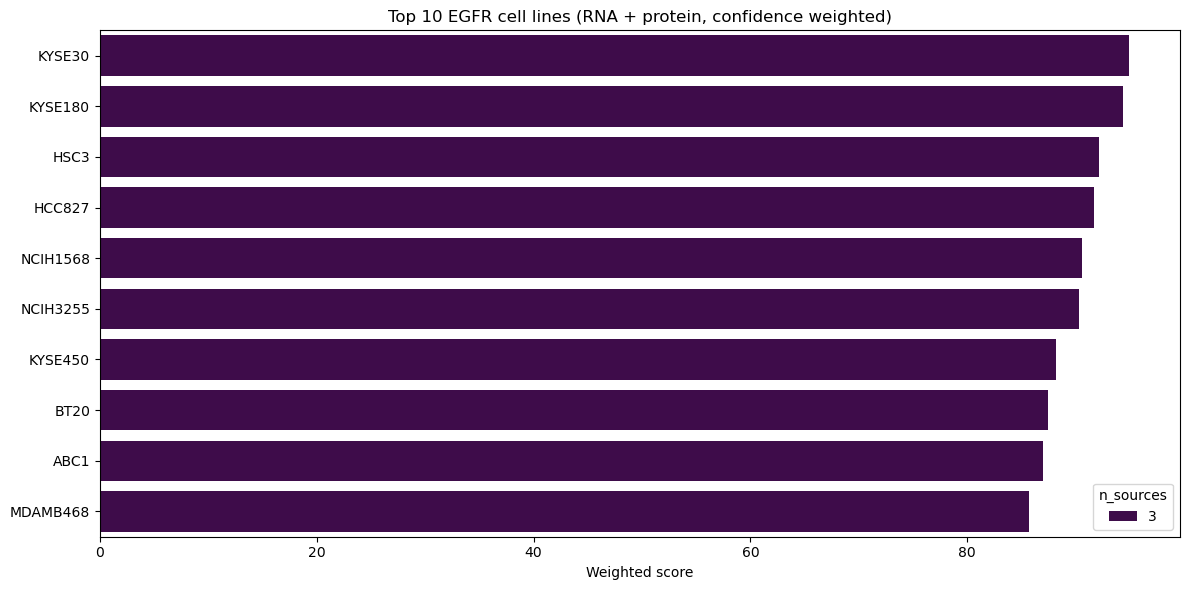

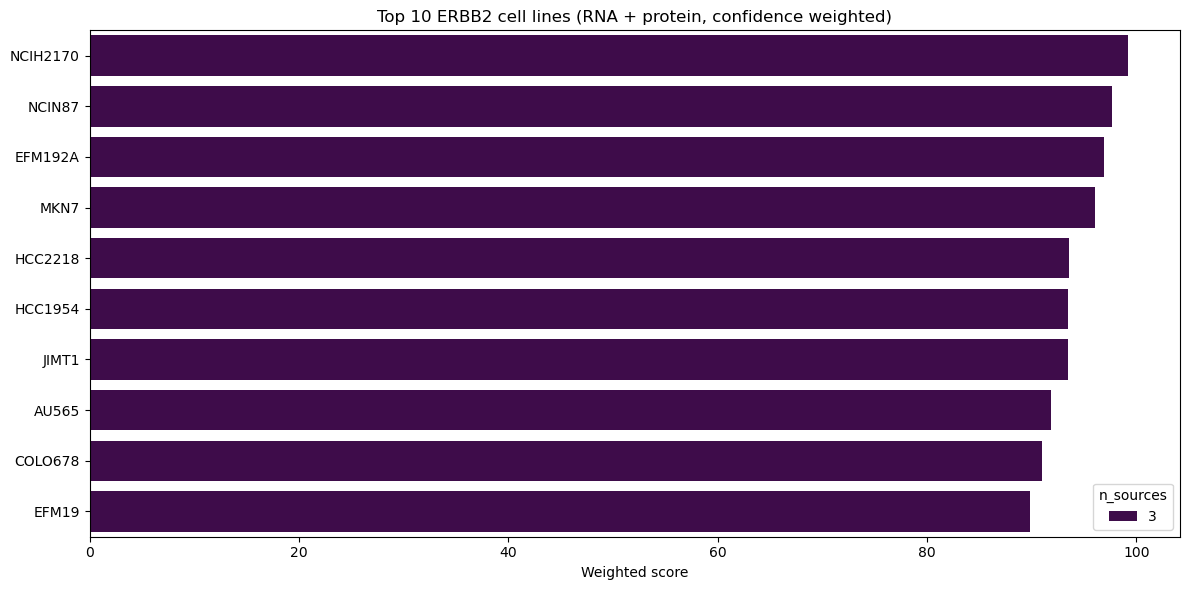

Saved both to ../../processed/


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# plot the top hits and save both gene results
def plot_top(df, gene_label, n=10):
    """Bar chart of the top n ranked cell lines, coloured by source coverage.

    Colouring by n_sources keeps coverage visible beside the score, so a high score resting on one source does not read the same as one resting on four.
    """
    top = df.head(n)
    plt.figure(figsize=(12, 6))
    sns.barplot(data=top, x="weighted_score", y="cell_line_name",
                hue="n_sources", palette="viridis", dodge=False)
    plt.title(f"Top {n} {gene_label} cell lines (RNA + protein, confidence weighted)")
    plt.xlabel("Weighted score")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

plot_top(egfr, "EGFR")
plot_top(erbb2, "ERBB2")

egfr.to_parquet("../../processed/ENSG00000146648_composite_baseline.parquet")
erbb2.to_parquet("../../processed/ENSG00000141736_composite_baseline.parquet")
print("Saved both to ../../processed/")

In [16]:
def show_results(df, n=10):
    """Return the top n rows with the columns worth reading side by side.

    Drops the intermediate value and spread columns and keeps the per-source percentiles next to the combined scores, rounded for display.
    """
    cols = ["cell_line_name", "primary_disease", "lineage",
            "depmap_percentile", "hpa_percentile", "geo_percentile",
            "protein_percentile", "protein_intensity",
            "evidence_score", "n_sources", "confidence_score", "weighted_score"]
    return df[cols].head(n).round(2)

show_results(egfr)

,cell_line_name,primary_disease,lineage,depmap_percentile,hpa_percentile,geo_percentile,protein_percentile,protein_intensity,evidence_score,n_sources,confidence_score,weighted_score
0,KYSE30,Esophageal Cancer,esophagus,99.26,99.46,98.98,97.60,3.11,98.42,3,0.96,94.89
1,KYSE180,Esophageal Cancer,esophagus,97.16,98.19,94.06,98.93,3.44,97.70,3,0.97,94.36
2,HSC3,Head and Neck Cancer,upper_aerodigestive,98.17,97.65,96.77,94.13,2.66,95.83,3,0.96,92.19
3,HCC827,Lung Cancer,lung,99.86,99.73,98.81,94.93,2.72,97.20,3,0.94,91.65
4,NCIH1568,Lung Cancer,lung,98.99,99.37,99.66,93.87,2.66,96.60,3,0.94,90.62
5,NCIH3255,Lung Cancer,lung,99.53,99.55,98.64,93.07,2.47,96.15,3,0.94,90.33
6,KYSE450,Esophageal Cancer,esophagus,99.32,98.73,93.38,91.73,2.36,94.44,3,0.93,88.20
7,BT20,Breast Cancer,breast,98.44,98.01,88.46,96.00,2.87,95.48,3,0.92,87.46
8,ABC1,Lung Cancer,lung,92.77,94.30,98.47,90.13,2.20,92.66,3,0.94,86.97
9,MDAMB468,Breast Cancer,breast,99.59,99.64,92.02,93.60,2.65,95.34,3,0.90,85.68


In [17]:
def rank_without_agreement(ensembl_id, depmap, hpa, geo, fact_prot, dim,
                           penalty=0.75, rna_weight=0.5):
    """Same as rank_cell_lines but with the cross-source agreement term removed."""
    df = rank_cell_lines(ensembl_id, depmap, hpa, geo, fact_prot, dim,
                         penalty=penalty, rna_weight=rna_weight)

    c_cols = [f"{s}_conf" for s in ["depmap", "hpa", "geo"]]

    # coverage x pairing confidence, dropping the 1/(1+source_std/100) factor
    df["confidence_score"] = (df["n_sources"] / 3) * df[c_cols].mean(axis=1)
    df["weighted_score"] = df["evidence_score"] * df["confidence_score"]

    return df.sort_values("weighted_score", ascending=False).reset_index(drop=True)


controls = {"ACH-001328": "A431", "ACH-000012": "HCC827", "ACH-000109": "NCIH3255"}

with_agr = rank_cell_lines("ENSG00000146648", depmap, hpa, geo, fact_prot, dim)
without   = rank_without_agreement("ENSG00000146648", depmap, hpa, geo, fact_prot, dim)

print(f"{'control':<10} {'with':>6} {'without':>8}  {'source_std':>10}")
for ach, name in controls.items():
    a = with_agr.index[with_agr["ACH_ID"] == ach]
    b = without.index[without["ACH_ID"] == ach]
    std = with_agr.loc[a[0], "source_std"] if len(a) else float("nan")
    print(f"{name:<10} {a[0]+1 if len(a) else None:>6} {b[0]+1 if len(b) else None:>8}  {std:>10.2f}")

control      with  without  source_std
A431           34       38        1.05
HCC827          4        4        0.29
NCIH3255        6        6        0.26


In [18]:
import duckdb
pdir = "../../data/parquet"

depmap_lines = duckdb.sql(f"SELECT COUNT(DISTINCT ACH_ID) AS n FROM read_parquet('{pdir}/fact_expression_depmap.parquet')").df()
dim_lines = duckdb.sql(f"SELECT COUNT(DISTINCT ach_id) AS n FROM read_parquet('{pdir}/dim_cell_lines.parquet')").df()
print("depmap:", depmap_lines["n"][0], "| dim_cell_lines:", dim_lines["n"][0])

depmap: 1479 | dim_cell_lines: 2220


In [19]:
import duckdb
pdir = "../../data/parquet"

q = f"""
SELECT
  (SELECT COUNT(DISTINCT ach_id) FROM read_parquet('{pdir}/dim_cell_lines.parquet')) AS in_dim,
  (SELECT COUNT(DISTINCT ACH_ID) FROM read_parquet('{pdir}/fact_expression_depmap.parquet')) AS in_depmap,
  (SELECT COUNT(DISTINCT ACH_ID) FROM read_parquet('{pdir}/fact_expression_hpa.parquet')) AS in_hpa,
  (SELECT COUNT(DISTINCT ACH_ID) FROM read_parquet('{pdir}/geo.parquet')) AS in_geo
"""
print(duckdb.sql(q).df())

   in_dim  in_depmap  in_hpa  in_geo
0    2220       1479    1105     589


In [20]:
q = f"""
SELECT COUNT(DISTINCT ach_id) AS n FROM (
  SELECT CAST(ACH_ID AS VARCHAR) AS ach_id FROM read_parquet('{pdir}/fact_expression_depmap.parquet')
  UNION
  SELECT CAST(ACH_ID AS VARCHAR) FROM read_parquet('{pdir}/fact_expression_hpa.parquet')
  UNION
  SELECT CAST(ACH_ID AS VARCHAR) FROM read_parquet('{pdir}/geo.parquet')
)
"""
print(duckdb.sql(q).df())

      n
0  1581
